![](https://drive.switch.ch/index.php/s/wx4IZKlmh51mehx/download)
# Project work
(Version 2025-11-14)
## Topic: Bushfires Australia (2019-2020)
Bushfires occur frequently during the summer months (December - February; or already slighlty earlier during the year) in Australia. The 2019-2020 fires gathered a lot of attention. The peak fires in Eastern Australia happened between December 2019 and January 2020, but the earliest fires were documented already in June 2019 and some lasted until May 2020. Apart from the economic losses such fires can have a severe impact on the environment, wildlife, and cause severe health issues for inhabitants in nearby (and even far away) cities.

Other noticeable bushfires occured in 2003 (December 2002 to March 2003) in Eastern Australia.

## Possible tasks for your project work:
- Can you identify the bushfires (2019-2020) from the NDVI data?
- Are NDVI values of burnt areas significantly different compared to the previous year(s)?
- What biomes (landcover and/or elevation) are affected the most?
- ...


### Data

> All datasets were prepared to have the same spatial resolution of 500 m and come in a UTM Zone 55 South projection.


**NDVI** data for the region (Fig.1) are from the Moderate Resolution Imager Spectroradiometer (MODIS) MOD13Q1 dataset (as introduced in the course earlier (TP1&2); https://lpdaac.usgs.gov/products/mod13q1v006/ ; https://ladsweb.modaps.eosdis.nasa.gov/missions-and-measurements/products/MOD13Q1). The datasets were downloaded and prepared for you already. The scale factor has not been applied yet. The scale factor is 10000. Only February NDVI scenes (julian day `033` = `~February 2nd`) were prepared to keep the data amount limited. February provides a good idea of how the vegetation looks like at the end summer (southern hemisphere summer!).

Three **landcover** classifications for the years 2017, 2018, 2019 are provided. They result from the MODIS MCD12Q1(https://lpdaac.usgs.gov/products/mcd12q1v006/) product, using the classification scheme "FAO-Land Cover Classification System" (LCCS2 - https://lpdaac.usgs.gov/documents/101/MCD12_User_Guide_V6.pdf Table 9). Which year you choose is up to you. There are slight differences in the classification.

A **digital elevation model (DEM)** is available that comes in the same spatial resolution and projection as the other files (prepared for your convenience). This dataset results from the Shuttle Radar Topography Mission (SRTM) dataset (https://www2.jpl.nasa.gov/srtm/), downloaded from https://dwtkns.com/srtm30m/.

![](https://drive.switch.ch/index.php/s/MzEuGrgKC1LC9xQ/download)
*Figure 1: Subset in Eastern Australia with the starting day (day of the year) in 2019. The burn date is derived from the MODIS MCD64A1 dataset (https://lpdaac.usgs.gov/products/mcd64a1v006/). The background shows the NDVI data from the MOD13Q1 dataset (https://lpdaac.usgs.gov/products/mod13q1v006/) for a single date.*

## Data and Methods
### Opening multiple files
You should use the introduced methods that were part of TP 1 & 2, including graphical representaiton of NDVI values using boxplots and maps. There were also methods shown on how to select certain pixels, e.g. using the DEM (elevation bands) and landcover classes (forest, barren, etc.).

Something new:
To load multiple raster files into a single dataset, you will find an adjusted code block hereafter. The example showcases how to load the MODIS MOD13Q1 February scenes. To load the landuse classification (MOD12Q1) or the digital elevation model, or terrain aspect, use the examples provided in TP1 and TP2. All data are located in the `../../data` folder.

### Statistical analysis
We expect you to perform a regression or (and - if you want to) a statistical test. Please refresh your memory on how to perform these by re-visiting the relevant notebooks of SGS.01101 and SGG.02101.
***

#### Example on loading multiple raster files at once:
The previous examples were only loading single raster files using the `xr.open_dataset()` function. Now, we load **all files with the same filename beginning (`MOD13Q1`).**

In [1]:
# loading required packages       # used for:
import xarray as xr               # raster data
import numpy as np                # general array and math functions
import matplotlib.pyplot as plt   # all plotting functions
import glob                       # folder and file search
from datetime import datetime     # to transform date-strings into dates a computer understands

In [2]:
path = '../../data/MODIS/centralCoast_500m_Feb/'  # location where the files are located
file_list = glob.glob(path+"MOD13Q1*.tif")        # all MOD13 (NDVI) files. The "*" is a wildcard -> any character allowed
file_list.sort()       # order is random before
scale_factor = 10000   # MOD13Q1 scale factor (see TP1)

In [3]:
# --- Function to extract date from filename ---
def extract_date(filename):
    # Example filename: "prefix.A2025325.suffix.tif"
    # Split by "." and find fragment beginning with "A"
    fragments = filename.split(".")
    for frag in fragments:
        if frag.startswith('A'):
            date_str = frag[1:]  # Remove "A"
            return datetime.strptime(date_str, "%Y%j")  # Parse as date
    return None  # If no matching fragment found


In [4]:
# Build list of xarray objects and dates
data_arrays = []
dates = []
for f in file_list:
    data_arrays.append(xr.open_dataset(f)/scale_factor)
    date = extract_date(f)
    if date:
        dates.append(date)

# Stack along a new 'time' dimension, using extracted dates
stack = xr.concat(data_arrays, dim='time')
stack = stack.assign_coords(time=("time", dates)).squeeze()


In [5]:
# Overview of all the loaded raster bands - note the "Dimensions". We have 20 time steps now (20 years)
stack

<xarray.Dataset> Size: 3MB
Dimensions:      (time: 20, y: 124, x: 329)
Coordinates:
    band         int64 8B 1
  * x            (x) float64 3kB 7.618e+05 7.623e+05 ... 9.253e+05 9.258e+05
  * y            (y) float64 992B 6.35e+06 6.35e+06 ... 6.289e+06 6.289e+06
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 160B 2002-02-02 2003-02-02 ... 2021-02-02
Data variables:
    band_data    (time, y, x) float32 3MB 0.43 0.5755 0.5183 ... nan nan nan

All NDVI values are stored as the variable `band_data`. You can access these data either way:
- `stack.band_data`
- `ndvi = stack.band_data` (here saved as a new variable called `ndvi`

In [6]:
ndvi = stack.band_data

### Plotting time series data
Similar to TP1, we can directly add a `.plot()` to plot the data. We need to specify some arguments:
- `col = <dimension>` - this informs the plotting function that we have multiple time steps and which variable should be plotted in the **col**umns
- `col_wrap = <n>` -  how many (`n`) scenes (time steps) per row

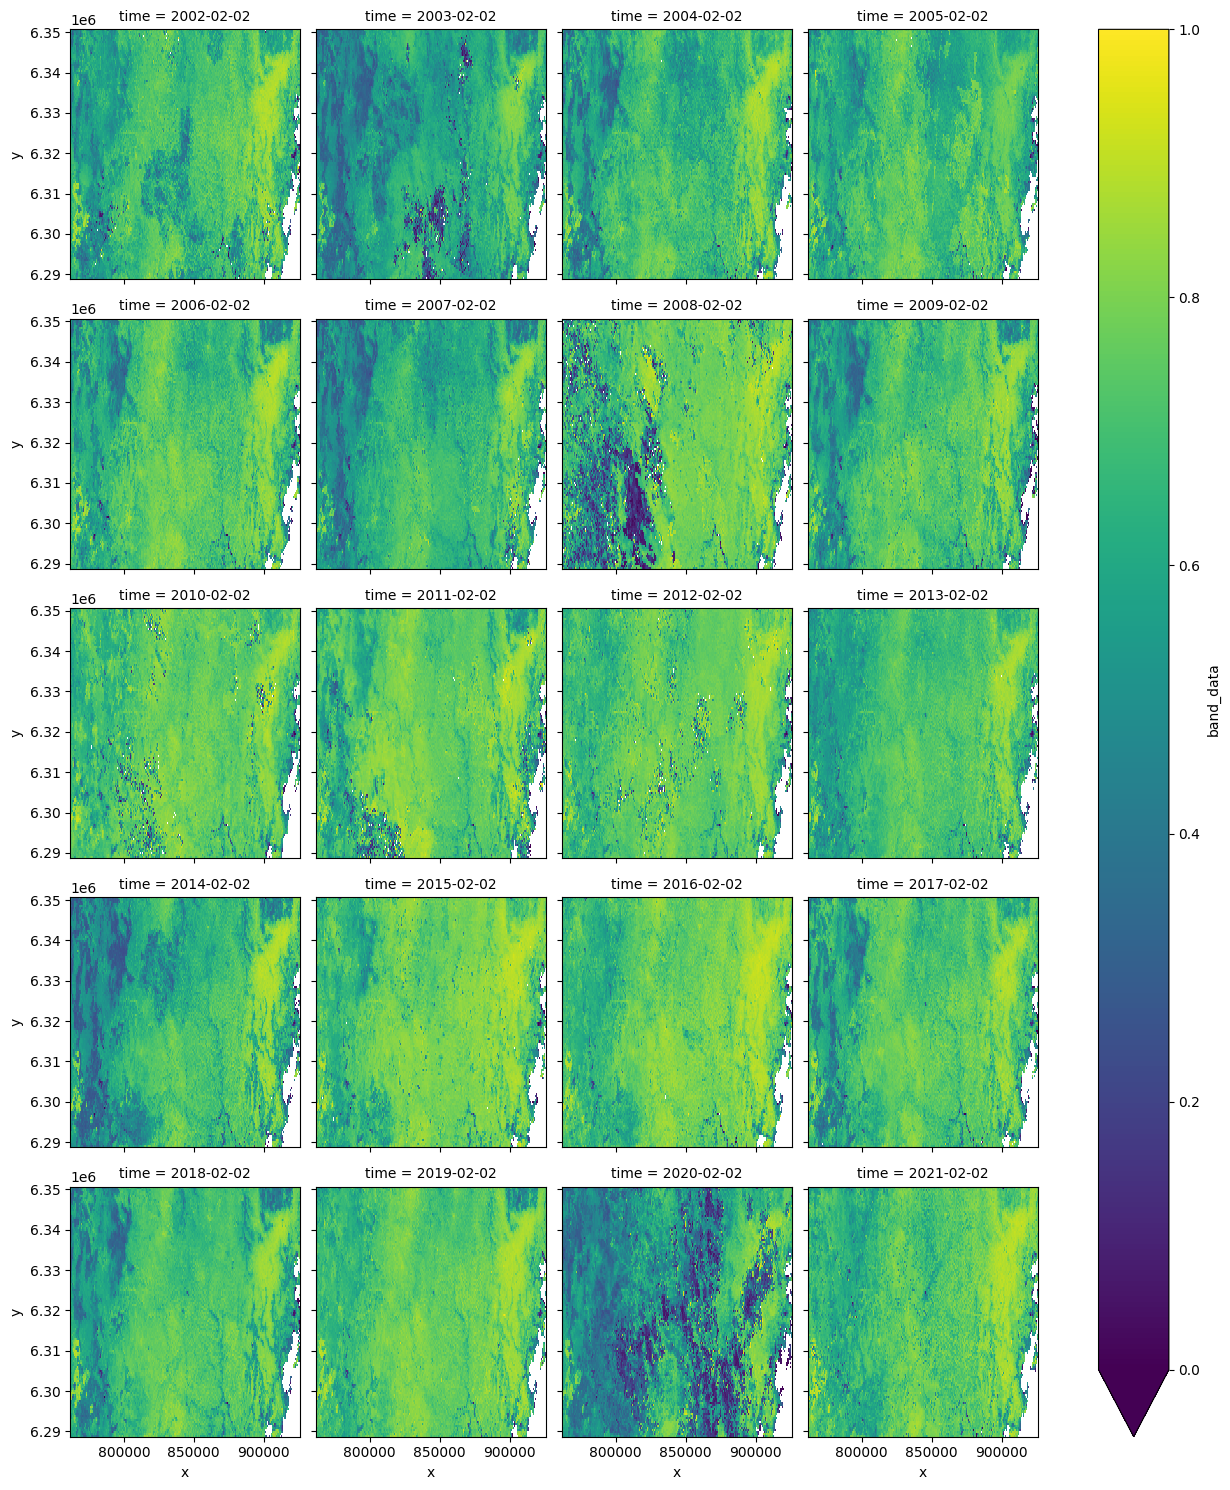

In [7]:
ndvi.plot(col='time', 
          col_wrap=4, 
          vmin=0, 
          vmax=1)

### Loading supporting data
In `TP1` we added the additional datasets:
- Digital elevation model
- Aspect
- Slope
- Landuse classification (MODIS MCD12Q1) for the years 2017, 2018, and 2019

In [10]:
filename_dem = path+"DEM_centralCoast.tif"  # digital elevation model
filename_lc = path+"MCD12Q1.A2017001.006.LC_Prop2.reproj.tif"  # 2017 landuse classification (2017,2018,2019 available!)
filename_asp = path+"ASP_centralCoast.tiff"  # aspect
filename_slp = path+"SLP_centralCoast.tiff"  # slope

In [11]:
# Load files
dem_dataset = xr.open_dataset(filename_dem)  # no scaling factor here!
dem = dem_dataset.band_data.squeeze()
lc_2017_dataset = xr.open_dataset(filename_lc)  # no scaling factor here!
lc_2017 = lc_2017_dataset.band_data.squeeze()
asp_dataset = xr.open_dataset(filename_asp)  # no scaling factor here!
asp = asp_dataset.band_data.squeeze()
slp_dataset = xr.open_dataset(filename_slp)  # no scaling factor here!
slp = slp_dataset.band_data.squeeze()

### Overview datasets
The following plots show you the different datasets available that are not NDVI.

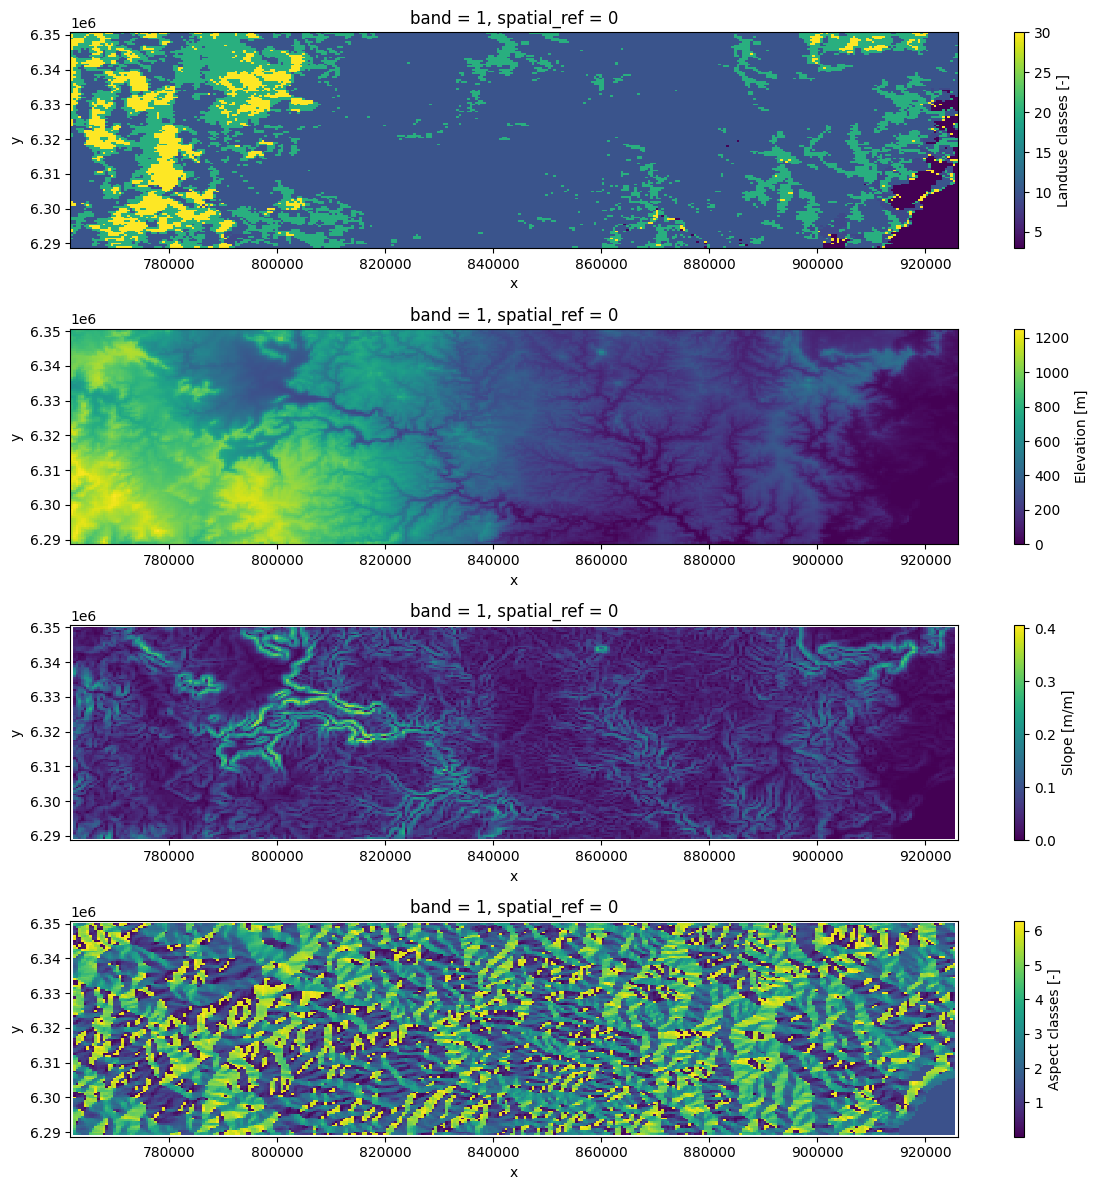

In [12]:
fig, ax = plt.subplots(4,1, figsize=(12,12))
lc_2017.plot(ax=ax[0], cbar_kwargs={"label": "Landuse classes [-]"})
dem.plot(ax=ax[1], cbar_kwargs={"label": "Elevation [m]"} )
slp.plot(ax=ax[2], cbar_kwargs={"label": "Slope [m/m]"} )
asp.plot(ax=ax[3], cbar_kwargs={"label": "Aspect classes [-]"} )
plt.tight_layout()

### Statistics over time
Until now, you applied statistics on individual raster files, or combined such statistics between different files. However, you can apply these functions also over the entire stack (over the dimension of time), e.g., to get the mean or standard deviation over time. If you want to apply the functions over a shorter period of time, see the examples below using the `.sel()` function.

In [13]:
rst_mean = ndvi.mean(dim='time')  # calculate the mean
rst_sd = ndvi.std(dim='time')     # calculate the standard deviation

/layers/paketo-buildpacks_pip-install/packages/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


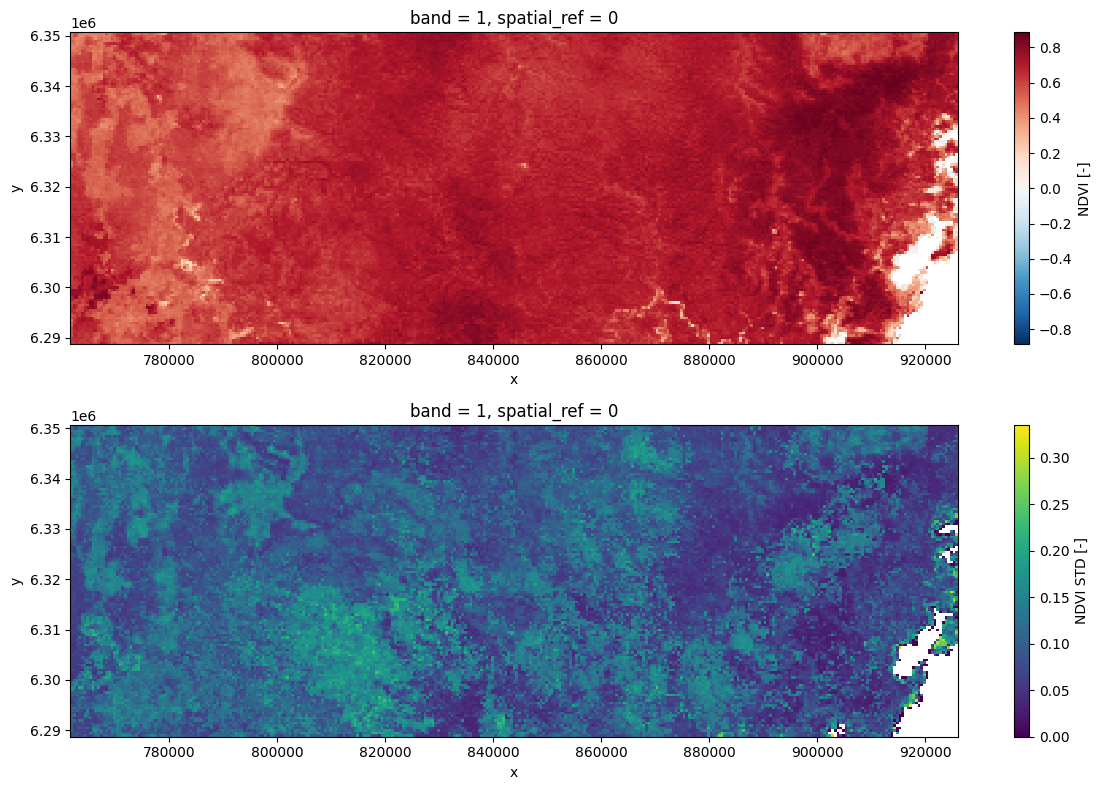

In [14]:
fig, ax = plt.subplots(2,1, figsize=(12,8))
rst_mean.plot(ax=ax[0], cbar_kwargs={"label": "NDVI [-]"} )
rst_sd.plot(ax=ax[1], cbar_kwargs={"label": "NDVI STD [-]"} )
plt.tight_layout()

## Selection of spatial or temporal subsets
In the previous lessons you have seen that you can use the `.where()` function to get the pixels ***where*** one dataset fulfills some condition, e.g., `dem.where(slope < 0.1)`  gives you all the pixels of the `dem` dataset where the `slope` dataset has values lower than 0.1 meters/meter.

Now the `.sel()` function is introduced. It allows you to pre-select time windows and spatial windows.

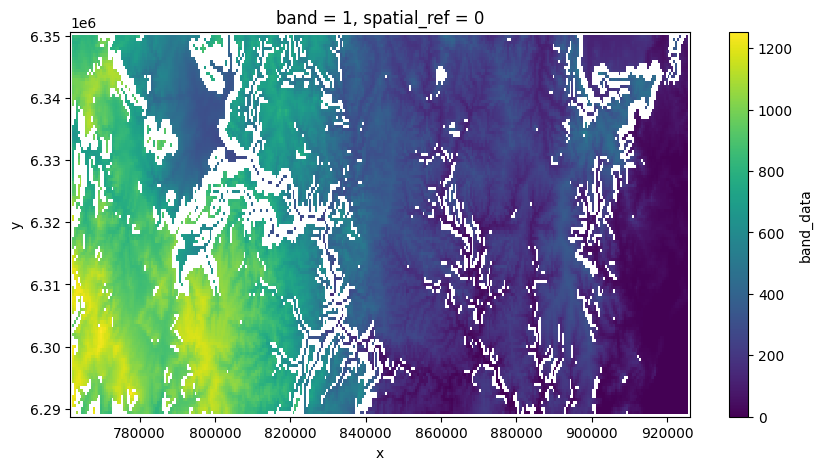

In [15]:
# Example with `where()` - over the entire spatial extent
dem.where(slp<0.1).plot( figsize=(10,5))

### Statistics over a spatial extent
With `.sel()` you can define a spatial point, or a spatial window. You need to identify a point in your study area first. Look at the map and select a `x` and `y` value - note that the coordinates are UTM projection and that the values on the axes might be multiplied with `1e6` (one million). The `slice` command allows you to define a start and end coordinate (also over time):
- `slice(<dim> = slice(<start>, <end>))`
- dim - the dimension over which to subset. In this example over the `x` and `y` dimension
- NOTE: the y-dimension is reversed because we start selecting pixels from **the top to the bottom** --> reversed order.


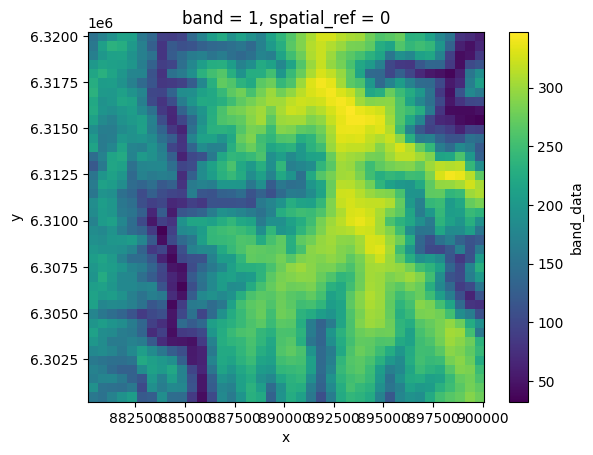

In [16]:
dem.sel(x=slice(880000,900000),
        y=slice(6320000,6300000)).plot()

### Selection of specific time steps
The same works over time with `.sel()`. Now the dimension is `time=`. The `.sel(time = slice())` function recognizes multiple time formats. As you only have one time scene per year (always February), you can simply put in the years that you are interested in.

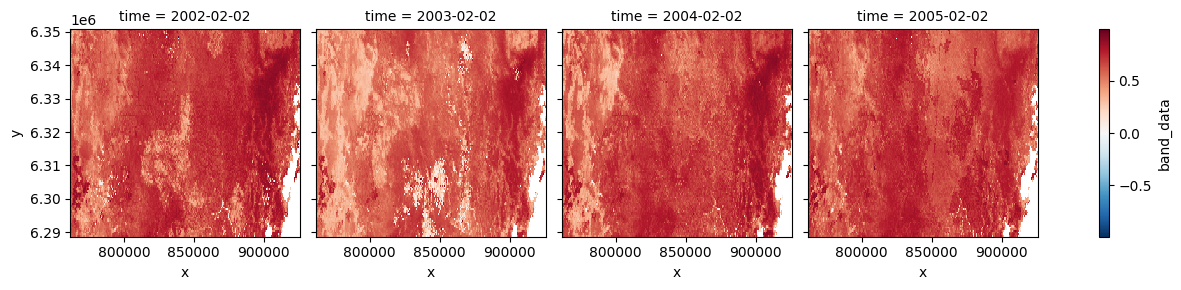

In [17]:
ndvi_2002to2005 = ndvi.sel(time=slice("2002", "2005"))
ndvi_2002to2005.plot(col='time')

From a selection like this, you can derive statistics in the same way as shown before. For example, if you want the `.mean()` over this 2002 to 2005 period, you simply apply it after the selection:

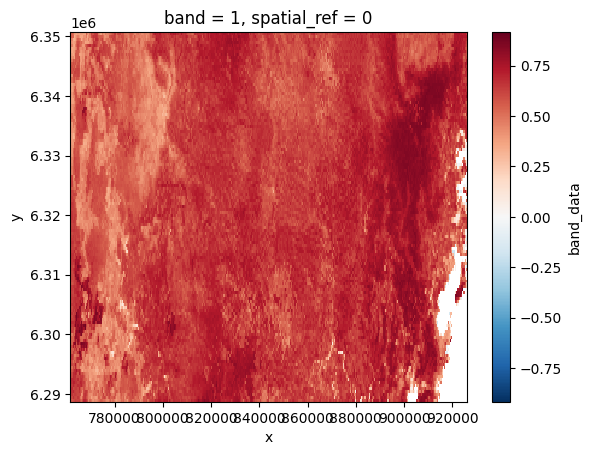

In [18]:
ndvi_2002to2005_mean = ndvi_2002to2005.mean(dim='time')
ndvi_2002to2005_mean.plot()

## Extracting data 
To make a boxplot or apply a statistical test or regression analysis, you select the actual data points of the `xarray.DataArray` as follows (same as in TP1).


In [19]:
# single layer (no time dimension):
ndvi_2002to2005_mean.values

array([[0.401575  , 0.542475  , 0.5048    , ..., 0.72135   , 0.73352504,
        0.64295   ],
       [0.40185   , 0.54497504, 0.5433    , ..., 0.737     , 0.73615   ,
        0.71235   ],
       [0.43820003, 0.450875  , 0.34045002, ..., 0.69299996, 0.7019    ,
        0.661175  ],
       ...,
       [0.6415    , 0.65720004, 0.62185   , ...,        nan,        nan,
               nan],
       [0.581325  , 0.61335003, 0.67252505, ...,        nan,        nan,
               nan],
       [0.572825  , 0.575125  , 0.599725  , ...,        nan,        nan,
               nan]], shape=(124, 329), dtype=float32)

### Remove nan data
The data are now of type `array` (here 3 dimensional with the first dimension being the time). Some plotting functions require to remove the "nan" (not a number / missing data) values. The example below shows this for the temporal subset:

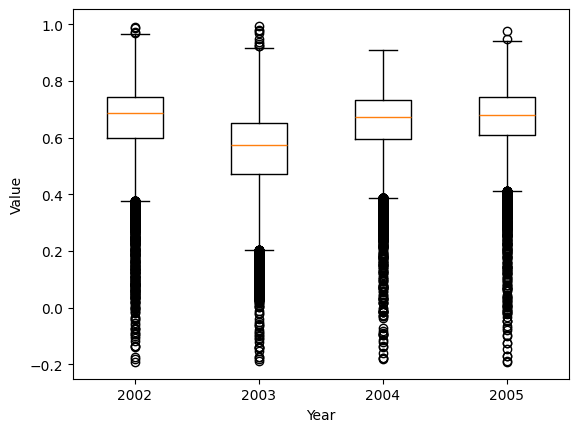

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Flatten each time slice (make it 1D)
# AND assign each set of datapoints as an element of a list called "data_for_boxplot"
data_for_boxplot = [ndvi_2002to2005.values[i].flatten() for i in range(ndvi_2002to2005.shape[0])]

# And remove NaNs explicitly
cleaned_data = [group[~np.isnan(group)] for group in data_for_boxplot]

years = ['2002', '2003', '2004', '2005']

plt.boxplot(cleaned_data, tick_labels=years)
plt.xlabel('Year')
plt.ylabel('Value')
plt.title('')
plt.show()

For a test, you want to have **one or two** samples. We have not introduced any methods where you would immediately apply a test on more than two samples. HINT: you can treat multiple years (e.g. 2002 to 2004) as one sample, and the other year (2005) as the second sample. You would again start by selecting the data from the `.values` array object.

In [22]:
# selecting the first 3 years (0:3 - reading: "from index 0 to, but not including, index 3)
sample1 = ndvi_2002to2005.values[0:3,:,:]
# selecting the last year (index 3)
sample2 = ndvi_2002to2005.values[3,:,:]  


In [23]:
from scipy.stats import mannwhitneyu

# Flatten and concatenate first 3 years into one 1D array
sample1_flat = sample1.flatten()
# Flatten last year into 1D array
sample2_flat = sample2.flatten()

# Remove NaNs from both samples
sample1_clean = sample1_flat[~np.isnan(sample1_flat)]
sample2_clean = sample2_flat[~np.isnan(sample2_flat)]

# Perform Mann-Whitney U test (two-sided)
statistic, pvalue = mannwhitneyu(sample1_clean, sample2_clean, alternative='two-sided')

print(f'Mann-Whitney U statistic: {statistic}')
print(f'p-value: {pvalue}')

if pvalue < 0.05:
    print("Reject null hypothesis: samples have significantly different distributions.")
else:
    print("Fail to reject null hypothesis: samples do not have significantly different distributions.")

Mann-Whitney U statistic: 1929046433.5
p-value: 0.0
Reject null hypothesis: samples have significantly different distributions.


## Tests

You have seen already possible ways to test different samples for 
- normality
- difference in variance
- difference in means
- difference in distributions

Follow the selection of a suitable test based on the flow chart in SGS.01101.

You can always reach out to ask about your approach and problems:
- eric.pohl@unifr.ch
- horst.machguth@unifr.ch
